<a href="https://colab.research.google.com/github/P37r/ClassRepo/blob/main/Algorithmic_Sports_Betting_Copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

base = "https://sports.core.api.espn.com"

url = base + "/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/plays?limit=400"

data = requests.get(url).json()

plays = []

for item in data["items"]:
    play_url = item["$ref"]
    play_data = requests.get(play_url).json()
    plays.append(play_data)

print(len(plays))


url = base + "/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/probabilities?limit=200"

data = requests.get(url).json()

probs = []

for item in data["items"]:
    prob_url = item["$ref"]
    prob_data = requests.get(prob_url).json()
    probs.append(prob_data)

prob_dict = {}

for p in probs:

    ref = p["play"]["$ref"]

    play_id = ref.split("/")[-1].split("?")[0]

    prob_dict[play_id] = p

rows = []

for play in plays:

    play_id = play["id"]

    if play_id in prob_dict:
        win_prob = prob_dict[play_id]["homeWinPercentage"]
    else:
        win_prob = None

    rows.append({
        "play_id": play_id,
        "text": play.get("text"),
        "win_prob": win_prob
    })

rows[200]

206


In [ ]:
plays[4]

{'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/plays/401772988106?lang=en&region=us',
 'id': '401772988106',
 'sequenceNumber': '10600',
 'type': {'id': '24', 'text': 'Pass Reception', 'abbreviation': 'REC'},
 'text': '(Shotgun) S.Darnold pass short left to A.Barner to NE 40 for 15 yards (C.Woodson).',
 'shortText': 'Sam Darnold Pass Complete for 15 Yds to AJ Barner',
 'alternativeText': '(Shotgun) S.Darnold pass short left to A.Barner to NE 40 for 15 yards (C.Woodson).',
 'shortAlternativeText': 'Sam Darnold Pass Complete for 15 Yds to AJ Barner',
 'awayScore': 0,
 'homeScore': 0,
 'period': {'number': 1},
 'clock': {'value': 830.0, 'displayValue': '13:50'},
 'scoringPlay': False,
 'priority': False,
 'scoreValue': 0,
 'modified': '2026-02-09T03:39Z',
 'team': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/seasons/2025/teams/26?lang=en&region=us'},
 'participants': [{'athlete': {'$ref': 'http:/

In [ ]:
for key, value in plays[-2].items():
    print(f"{key}: {value}")

$ref: http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/plays/4017729884626?lang=en&region=us
id: 4017729884626
sequenceNumber: 462600
type: {'id': '24', 'text': 'Pass Reception', 'abbreviation': 'REC'}
text: (No Huddle, Shotgun) D.Maye pass short right to T.Henderson to SEA 29 for 24 yards (J.Love).
shortText: Drake Maye Pass Complete for 24 Yds to TreVeyon Henderson
alternativeText: (No Huddle, Shotgun) D.Maye pass short right to T.Henderson to SEA 29 for 24 yards (J.Love).
shortAlternativeText: Drake Maye Pass Complete for 24 Yds to TreVeyon Henderson
awayScore: 29
homeScore: 13
period: {'number': 4}
clock: {'value': 12.0, 'displayValue': '0:12'}
scoringPlay: False
priority: False
scoreValue: 0
modified: 2026-02-09T03:39Z
team: {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/seasons/2025/teams/17?lang=en&region=us'}
participants: [{'athlete': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/lea

## Get games_df_vs

In [ ]:
import json
import re
from time import sleep

import pandas as pd
import requests

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATE_START = "2025-11-01"
DATE_END   = "2026-03-10"
INTERVAL   = "max"   # full history window
FIDELITY   = 500     # number of points requested from CLOB
# ─────────────────────────────────────────────────────────────────────────────

GAMMA_URL = "https://gamma-api.polymarket.com/events"
CLOB_URL  = "https://clob.polymarket.com/prices-history"

# ── STEP 1: Fetch NFL events ──────────────────────────────────────────────────
def fetch_nfl_events(date_start, date_end):
    all_events, offset = [], 0
    while True:
        params = {
            "limit": 200,
            "offset": offset,
            "closed": True,
            "tag_slug": "nfl",
            "start_date_min": date_start,
            "start_date_max": date_end,
        }
        r = requests.get(GAMMA_URL, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        if not data:
            break
        all_events.extend(data)
        print(f"  Fetched {len(all_events)} NFL events...")
        if len(data) < 200:
            break
        offset += 200
    return all_events

# ── STEP 2: Filter to actual game markets only ────────────────────────────────
GAME_PATTERNS = [
    r"will the .+ beat the .+\?",
    r"will .+ beat .+\?",
    r"will .+ win .+\?",
    r".+ vs\.? .+",
]

EXCLUDE_KEYWORDS = [
    "rookie of the year", "mvp", "super bowl mvp", "most passing",
    "most rushing", "most receiving", "division", "conference",
    "make the playoffs", "win the super bowl", "nfc", "afc",
    "heisman", "coach", "draft", "total wins", "over/under"
]

def is_game_market(question: str) -> bool:
    q = str(question).lower()
    if any(kw in q for kw in EXCLUDE_KEYWORDS):
        return False
    return any(re.search(p, q) for p in GAME_PATTERNS)

def _parse_token_ids(raw_value):
    if raw_value is None:
        return []
    if isinstance(raw_value, list):
        return [str(v).strip() for v in raw_value if str(v).strip()]
    if isinstance(raw_value, str):
        raw_value = raw_value.strip()
        if not raw_value:
            return []
        try:
            parsed = json.loads(raw_value)
        except json.JSONDecodeError:
            return []
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    return []

def _extract_winner(market: dict) -> str | None:
    """
    Try multiple fields to find the resolution outcome.
    Gamma API is inconsistent — different endpoints use different keys.
    """
    for key in ("winner", "resolutionTitle", "outcome", "resolvedOutcome"):
        val = market.get(key)
        if val is not None and str(val).strip().lower() not in ("", "none", "null"):
            return str(val).strip()
    return None

def extract_game_markets(events):
    rows = []
    for event in events:
        for market in event.get("markets", []) or []:
            q = market.get("question", "")
            if not is_game_market(q):
                continue

            token_ids = _parse_token_ids(market.get("clobTokenIds"))

            rows.append({
                "event_id":    event.get("id"),
                "event_title": event.get("title"),
                # ✅ end_date is the actual game time; start_date is when the market opened
                "game_date":   market.get("endDate") or event.get("endDate"),
                "market_open": event.get("startDate"),
                "market_id":   market.get("id"),
                "condition_id": market.get("conditionId"),
                # ✅ Store both YES and NO token ids
                "yes_token_id": token_ids[0] if len(token_ids) > 0 else None,
                "no_token_id":  token_ids[1] if len(token_ids) > 1 else None,
                # Keep token_id as YES for backward compatibility with CLOB fetcher
                "token_id":    token_ids[0] if len(token_ids) > 0 else None,
                "question":    q,
                # ✅ Cast volume to float safely
                "volume":      float(market.get("volume") or 0),
                "liquidity":   float(market.get("liquidity") or 0),
                # ✅ Try multiple fields to find the winner
                "winner":      _extract_winner(market),
            })
    return pd.DataFrame(rows)

def attach_token_ids_from_events(games_df: pd.DataFrame, events) -> pd.DataFrame:
    """Backfill token_id by market_id in case games_df was created before token_id existed."""
    if games_df.empty or "market_id" not in games_df.columns:
        return games_df.copy()

    mapping_rows = []
    for event in events:
        for market in event.get("markets", []) or []:
            token_ids = _parse_token_ids(market.get("clobTokenIds"))
            mapping_rows.append({
                "market_id":    market.get("id"),
                "token_id_event": token_ids[0] if token_ids else None,
            })

    map_df = pd.DataFrame(mapping_rows)
    if map_df.empty:
        out = games_df.copy()
        if "token_id" not in out.columns:
            out["token_id"] = None
        return out

    map_df = map_df.dropna(subset=["market_id"]).drop_duplicates("market_id", keep="first")

    out = games_df.copy()
    if "token_id" not in out.columns:
        out["token_id"] = None

    out = out.merge(map_df, on="market_id", how="left")
    out["token_id"] = out["token_id"].fillna(out["token_id_event"])
    out = out.drop(columns=["token_id_event"])
    return out

# ── STEP 3: Fetch price history using CLOB token_id ──────────────────────────
def fetch_price_history(token_id: str, interval: str = "max", fidelity: int = 500):
    token = "" if token_id is None else str(token_id).strip()
    if not token:
        return pd.DataFrame(), "missing_token_id"

    params = {"market": token, "interval": interval, "fidelity": fidelity}
    try:
        r = requests.get(CLOB_URL, params=params, timeout=20)
        if r.status_code != 200:
            return pd.DataFrame(), f"http_{r.status_code}"

        payload = r.json()
        history = payload.get("history", []) if isinstance(payload, dict) else []
        if not history:
            return pd.DataFrame(), "empty_history"

        df = pd.DataFrame(history)
        if not {"t", "p"}.issubset(df.columns):
            return pd.DataFrame(), "unexpected_schema"

        df["timestamp"] = pd.to_datetime(df["t"], unit="s", errors="coerce")
        df["yes_price"]  = pd.to_numeric(df["p"], errors="coerce")
        df = df.dropna(subset=["timestamp", "yes_price"]).sort_values("timestamp")
        if df.empty:
            return pd.DataFrame(), "no_valid_points"

        df["no_price"] = 1 - df["yes_price"]
        return df[["timestamp", "yes_price", "no_price"]], "ok"
    except Exception as e:
        return pd.DataFrame(), f"error:{type(e).__name__}"

# ── STEP 4: Build full time-series dataset + status table ────────────────────
def build_price_timeseries(games_df: pd.DataFrame, interval: str = "max", fidelity: int = 500):
    all_rows    = []
    status_rows = []
    total       = len(games_df)

    for pos, (_, row) in enumerate(games_df.iterrows(), start=1):
        token   = row.get("token_id")
        history, reason = fetch_price_history(token, interval=interval, fidelity=fidelity)

        status = {
            "market_id":   row.get("market_id"),
            "condition_id": row.get("condition_id"),
            "token_id":    token,
            "question":    row.get("question"),
            "event_title": row.get("event_title"),
            "status":      "ok" if not history.empty else "not_possible",
            "reason":      reason,
            "points":      len(history),
        }
        status_rows.append(status)

        if not history.empty:
            history["market_id"]   = row.get("market_id")
            history["condition_id"] = row.get("condition_id")
            history["token_id"]    = token
            history["question"]    = row.get("question")
            history["event_title"] = row.get("event_title")
            # ✅ game_date now correctly uses end_date (actual game time)
            history["game_date"]   = row.get("game_date")
            history["winner"]      = row.get("winner")
            all_rows.append(history)

        if pos % 25 == 0 or pos == total:
            print(f"  processed {pos}/{total}")

        sleep(0.05)

    timeseries_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame(
        columns=[
            "timestamp", "yes_price", "no_price", "market_id", "condition_id",
            "token_id", "question", "event_title", "game_date", "winner"
        ]
    )
    status_df = pd.DataFrame(status_rows)
    return timeseries_df, status_df

# ── MAIN ──────────────────────────────────────────────────────────────────────
print("1. Fetching NFL events...")
events = fetch_nfl_events(DATE_START, DATE_END)

print("\n2. Filtering to game markets...")
games_df = extract_game_markets(events)
print(f"   Found {len(games_df)} game markets")
print(games_df[["question", "event_title", "yes_token_id", "no_token_id", "winner", "volume"]].head(10))

# ── Quick debug: inspect raw market keys from first event ─────────────────────
if events and events[0].get("markets"):
    print("\n[DEBUG] Raw market keys:", list(events[0]["markets"][0].keys()))

1. Fetching NFL events...
  Fetched 200 NFL events...
  Fetched 249 NFL events...

2. Filtering to game markets...
   Found 2342 game markets
                            question          event_title  \
0                Raiders vs. Broncos  Raiders vs. Broncos   
1      Raiders vs. Broncos: O/U 42.5  Raiders vs. Broncos   
2   Raiders vs. Broncos: 1H O/U 21.5  Raiders vs. Broncos   
3  Raiders vs. Broncos: 1H Moneyline  Raiders vs. Broncos   
4   Raiders vs. Broncos: 1H O/U 20.5  Raiders vs. Broncos   
5      Raiders vs. Broncos: O/U 41.5  Raiders vs. Broncos   
6   Raiders vs. Broncos: 1H O/U 22.5  Raiders vs. Broncos   
7                  Falcons vs. Colts    Falcons vs. Colts   
8        Falcons vs. Colts: O/U 48.5    Falcons vs. Colts   
9     Falcons vs. Colts: 1H O/U 24.5    Falcons vs. Colts   

                                        yes_token_id  \
0  5673973454693634924837058814536666838433418864...   
1  1074527365856602690568306049830619812064026863...   
2  258955595371088

In [ ]:

games_df_vs = games_df[
    games_df["question"].str.contains(r".+ vs\. .+", case=False, na=False, regex=True) &
    ~games_df["question"].str.contains(r"spread|-|O/U|Moneyline", case=False, na=False, regex=True) &
    games_df["event_title"].str.contains("vs", case=False, na=False)
]
print(list(games_df_vs['question']))


['Raiders vs. Broncos', 'Falcons vs. Colts', 'Saints vs. Panthers', 'Giants vs. Bears', 'Jaguars vs. Texans', 'Bills vs. Dolphins', 'Ravens vs. Vikings', 'Browns vs. Jets', 'Patriots vs. Buccaneers', 'Cardinals vs. Seahawks', 'Rams vs. 49ers', 'Lions vs. Commanders', 'Steelers vs. Chargers', 'Eagles vs. Packers', 'Jets vs. Patriots', 'Commanders vs. Dolphins', 'Panthers vs. Falcons', 'Buccaneers vs. Bills', 'Chargers vs. Jaguars', 'Bears vs. Vikings', 'Packers vs. Giants', 'Bengals vs. Steelers', 'Texans vs. Titans', '49ers vs. Cardinals', 'Seahawks vs. Rams', 'Ravens vs. Browns', 'Chiefs vs. Broncos', 'Lions vs. Eagles', 'Cowboys vs. Raiders', 'Bills vs. Texans', 'Jets vs. Ravens', 'Steelers vs. Bears', 'Patriots vs. Bengals', 'Giants vs. Lions', 'Vikings vs. Packers', 'Colts vs. Chiefs', 'Seahawks vs. Titans', 'Jaguars vs. Cardinals', 'Browns vs. Raiders', 'Eagles vs. Cowboys', 'Falcons vs. Saints', 'Buccaneers vs. Rams', 'Panthers vs. 49ers', 'Bears vs. Eagles', 'Chiefs vs. Cowboys'

## Get yes_token_id

Loading...

    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    POLYMARKET SUMMARY  —  SEA vs NE
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Total trades     :      391,949
    Unique wallets   :       31,646
    Date range       : 2026-02-08 → 2026-02-08

    VOLUME (USDC)
    ├─ Total         : $ 38,029,071.63
    ├─ Buy volume    : $ 31,175,157.74  (82.0%)
    ├─ Sell volume   : $  6,853,913.90  (18.0%)
    ├─ Avg per trade : $       97.0256
    └─ Max trade     : $    497,500.00

    PRICE
    ├─ Overall avg   :        0.6081
    ├─ Buy avg       :        0.6454
    ├─ Sell avg      :        0.4587
    ├─ Min           :        0.0005
    └─ Max           :        1.0000

    TRADE COUNTS
    ├─ Buys          :      313,665  (80.0%)
    └─ Sells         :       78,284  (20.0%)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    
look HERE!
2026-02-08 18:29:59-05:00
2026-02-08 22:30:01-05:00
✓ Saved: polymarket_summary.png


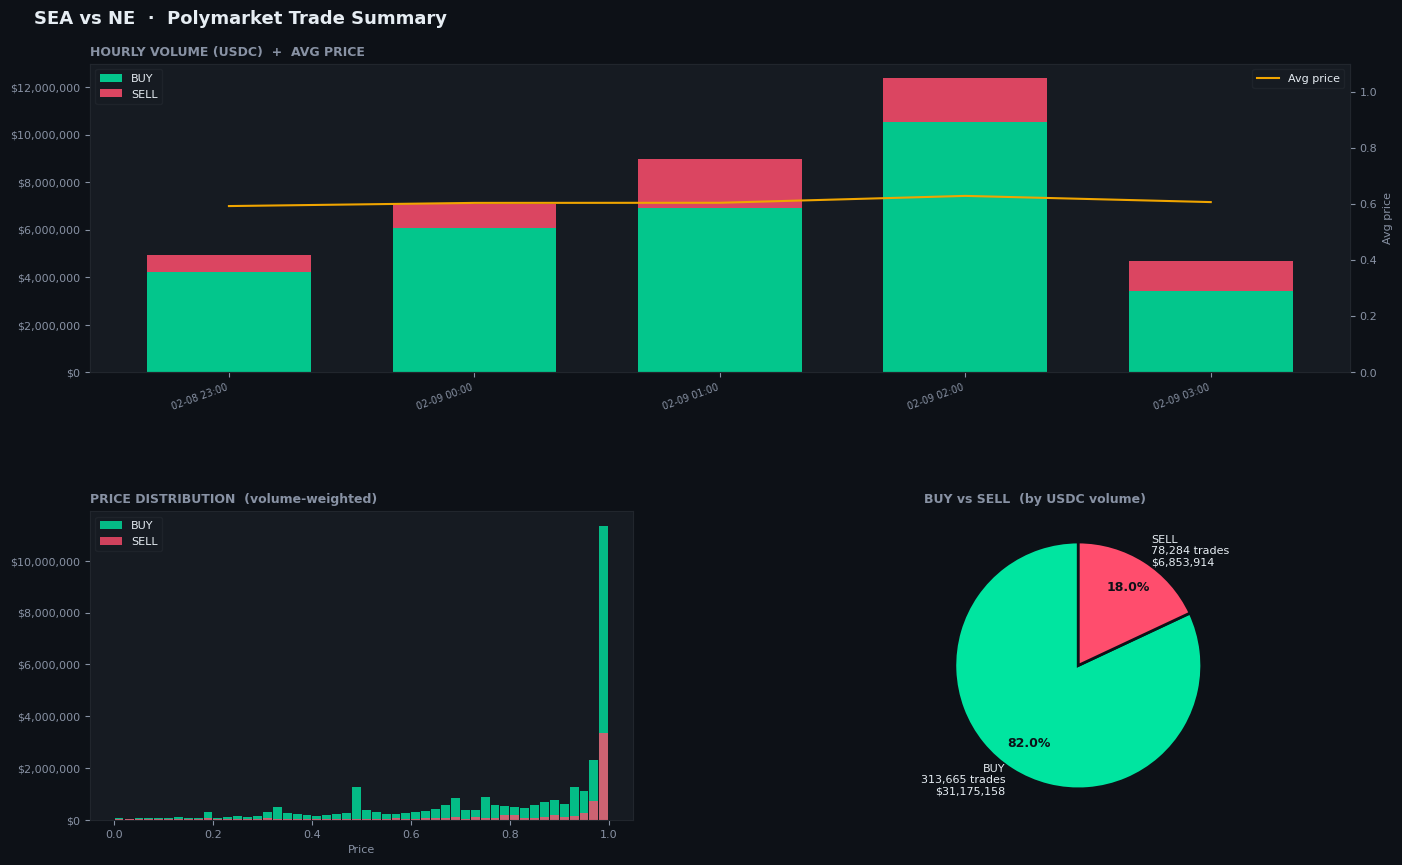

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

FILE = r"C:\Users\peter\OneDrive\Desktop\poly-trade-scan\nfl_trades\2025_SEA_vs_NE_2026-02-08.csv"

BG, PANEL, BORDER = "#0d1117", "#161b22", "#21262d"
TEXT, DIM, GOLD = "#e6edf3", "#8892a4", "#f0a500"
BUY_COLOR, SELL_COLOR = "#00e5a0", "#ff4d6d"

# ── Load ─────────────────────────────────────────────────────────────────────
print("Loading...")
df = pd.read_csv(FILE)

def analyze(df):

    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_convert("America/New_York")
    df["tokens"]     = pd.to_numeric(df["tokens"],     errors="coerce")
    df["price"]      = pd.to_numeric(df["price"],      errors="coerce")
    df["total_usdc"] = pd.to_numeric(df["total_usdc"], errors="coerce")
    df["hour"]       = df["timestamp"].dt.floor("h")

    buys  = df[df["side"] == "BUY"]
    sells = df[df["side"] == "SELL"]

    # ── Print summary ─────────────────────────────────────────────────────────────
    print(f"""
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    POLYMARKET SUMMARY  —  SEA vs NE
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Total trades     : {len(df):>12,}
    Unique wallets   : {df['wallet'].nunique():>12,}
    Date range       : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}

    VOLUME (USDC)
    ├─ Total         : ${df['total_usdc'].sum():>14,.2f}
    ├─ Buy volume    : ${buys['total_usdc'].sum():>14,.2f}  ({100*buys['total_usdc'].sum()/df['total_usdc'].sum():.1f}%)
    ├─ Sell volume   : ${sells['total_usdc'].sum():>14,.2f}  ({100*sells['total_usdc'].sum()/df['total_usdc'].sum():.1f}%)
    ├─ Avg per trade : ${df['total_usdc'].mean():>14,.4f}
    └─ Max trade     : ${df['total_usdc'].max():>14,.2f}

    PRICE
    ├─ Overall avg   : {df['price'].mean():>13.4f}
    ├─ Buy avg       : {buys['price'].mean():>13.4f}
    ├─ Sell avg      : {sells['price'].mean():>13.4f}
    ├─ Min           : {df['price'].min():>13.4f}
    └─ Max           : {df['price'].max():>13.4f}

    TRADE COUNTS
    ├─ Buys          : {len(buys):>12,}  ({100*len(buys)/len(df):.1f}%)
    └─ Sells         : {len(sells):>12,}  ({100*len(sells)/len(df):.1f}%)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    """)

    print("look HERE!")
    print(df['timestamp'].min())
    print(df['timestamp'].max())

    # ── Aggregate for plots ───────────────────────────────────────────────────────
    hourly    = df.groupby(["hour", "side"])["total_usdc"].sum().unstack(fill_value=0)
    hourly_px = df.groupby("hour")["price"].mean()
    price_bins = pd.cut(df["price"], bins=50)
    price_dist = df.groupby([price_bins, "side"])["total_usdc"].sum().unstack(fill_value=0)

    # ── Plot ──────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 9), facecolor=BG)
    fig.suptitle("SEA vs NE  ·  Polymarket Trade Summary",
                color=TEXT, fontsize=13, fontweight="bold", x=0.03, ha="left", y=0.98)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.32,
                        left=0.07, right=0.97, top=0.92, bottom=0.08)

    def style(ax, title):
        ax.set_facecolor(PANEL)
        ax.set_title(title, color=DIM, fontsize=9, fontweight="bold", loc="left", pad=6)
        ax.tick_params(colors=DIM, labelsize=8)
        for spine in ax.spines.values(): spine.set_edgecolor(BORDER)
        ax.yaxis.label.set_color(DIM)

    # 1. Hourly volume + price overlay ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    style(ax1, "HOURLY VOLUME (USDC)  +  AVG PRICE")
    if "BUY" in hourly.columns:
        ax1.bar(hourly.index, hourly["BUY"], color=BUY_COLOR, alpha=0.85,
                label="BUY", width=pd.Timedelta(minutes=40))
    if "SELL" in hourly.columns:
        bottom = hourly.get("BUY", pd.Series(0, index=hourly.index))
        ax1.bar(hourly.index, hourly["SELL"], color=SELL_COLOR, alpha=0.85,
                label="SELL", width=pd.Timedelta(minutes=40), bottom=bottom)
    ax2t = ax1.twinx()
    ax2t.plot(hourly_px.index, hourly_px.values, color=GOLD, linewidth=1.5, label="Avg price")
    ax2t.set_ylim(0, 1.1)
    ax2t.tick_params(colors=DIM, labelsize=8)
    ax2t.set_ylabel("Avg price", color=DIM, fontsize=8)
    for spine in ax2t.spines.values(): spine.set_edgecolor(BORDER)
    ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
    ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m-%d %H:%M"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=7)
    ax1.legend(facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT, fontsize=8, loc="upper left")
    ax2t.legend(facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT, fontsize=8, loc="upper right")

    # 2. Price distribution (volume-weighted) ─────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    style(ax3, "PRICE DISTRIBUTION  (volume-weighted)")
    bin_mids = [iv.mid for iv in price_dist.index]
    w = 1 / 50 * 0.9
    if "BUY" in price_dist.columns:
        ax3.bar(bin_mids, price_dist["BUY"],  width=w, color=BUY_COLOR,  alpha=0.8, label="BUY")
    if "SELL" in price_dist.columns:
        ax3.bar(bin_mids, price_dist["SELL"], width=w, color=SELL_COLOR, alpha=0.8, label="SELL")
    ax3.set_xlabel("Price", color=DIM, fontsize=8)
    ax3.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
    ax3.legend(facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT, fontsize=8)

    # 3. Buy/Sell donut ────────────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    style(ax4, "BUY vs SELL  (by USDC volume)")
    ax4.set_facecolor(PANEL)
    buy_vol  = buys["total_usdc"].sum()
    sell_vol = sells["total_usdc"].sum()
    wedges, texts, pcts = ax4.pie(
        [buy_vol, sell_vol],
        labels=[f"BUY\n{len(buys):,} trades\n${buy_vol:,.0f}",
                f"SELL\n{len(sells):,} trades\n${sell_vol:,.0f}"],
        colors=[BUY_COLOR, SELL_COLOR],
        autopct="%1.1f%%", startangle=90,
        textprops={"color": TEXT, "fontsize": 8},
        wedgeprops={"linewidth": 2, "edgecolor": BG},
        pctdistance=0.75)
    for p in pcts:
        p.set_fontweight("bold"); p.set_color(BG); p.set_fontsize(9)

    plt.savefig("polymarket_summary.png", dpi=150, bbox_inches="tight", facecolor=BG)
    print("✓ Saved: polymarket_summary.png")
    plt.show()
analyze(df)

In [ ]:
yes_token_id = int(games_df_vs.iloc[-1]["yes_token_id"])
no_token_id  = int(games_df_vs.iloc[-1]["no_token_id"])

df_yes = df[df["token_id"] == yes_token_id]
df_no  = df[df["token_id"] == no_token_id]

## Visualize Superbowl Example

In [ ]:
# import pandas as pd
full_market= pd.read_csv(r"C:\Users\peter\OneDrive\Desktop\poly-trade-scan\nfl_trades\2025_SEA_vs_NE_2026-02-08_full_market.csv")

In [ ]:
yes_full_market=full_market[full_market["token_id"] == yes_token_id]
no_full_market=full_market[full_market["token_id"] == no_token_id]

In [ ]:
yes_full_market

,block_number,timestamp,tx_hash,wallet,token_id,side,tokens,price,total_usdc
11855,82139118,2026-01-26T03:30:08+00:00,0x894f6fe41ef78b31438ca152800b61f1dc502b2806f9...,0x5faf6bb6a2a4272600e27a7c990f2284ab6f27bb,4643411015584103352938494998371898043870654387...,BUY,21466.9565,0.690000,14812.20
12012,82139120,2026-01-26T03:30:12+00:00,0xb97c4db449429afbd5139ff5aee249e45a5be90ad998...,0xcc8a1d017cdd63e89020406ad787734595a74b6c,4643411015584103352938494998371898043870654387...,BUY,72.4637,0.690001,50.00
12228,82139126,2026-01-26T03:30:24+00:00,0x6f40b937d23af0a96c21ff0f9d4ca46970fda8725c20...,0x32706644fe35a664eec3f9180716b512e659c396,4643411015584103352938494998371898043870654387...,BUY,4.2463,0.690012,2.93
12230,82139126,2026-01-26T03:30:24+00:00,0x1f01abc55ecfc2078afdc2248ca707ecd380e5c07616...,0xee43082bbe0f4389b6f36b14b5a0666aee15ea45,4643411015584103352938494998371898043870654387...,BUY,1.5211,0.710012,1.08
12284,82139128,2026-01-26T03:30:28+00:00,0x5bd7a619f2c8f46c15087e247ffd0ddf9f69e791f8a9...,0xee43082bbe0f4389b6f36b14b5a0666aee15ea45,4643411015584103352938494998371898043870654387...,BUY,1.5211,0.710012,1.08
...,...,...,...,...,...,...,...,...,...
16430662,82503776,2026-02-03T14:05:58+00:00,0x1bea06918491efeb94f87552a5d52086a8a9602b401d...,0xbd89e6f902e315e74f342dbfc98ece7aa155d749,4643411015584103352938494998371898043870654387...,BUY,2.8695,0.690016,1.98
16431023,82503784,2026-02-03T14:06:14+00:00,0xa7479393bcb41765d244c8213a9f5ac732e1885c7ac0...,0xd3ca12585c9839e60b6e8615a831120aac7da8f4,4643411015584103352938494998371898043870654387...,SELL,30.0000,0.680000,20.40
16431426,82503792,2026-02-03T14:06:30+00:00,0x5da5b17023ce39ee1777f62354dd758e1fd1c1875341...,0xd282d917ccb8ba775a6c8e6e6a5ba1064e6aa904,4643411015584103352938494998371898043870654387...,BUY,7.2463,0.690007,5.00
16433221,82503834,2026-02-03T14:07:54+00:00,0x687a3cc792bc530d8c8c3ef2b629a4a2d7650c7b1032...,0x7d77c1f7fa3e509bad9206476856ad358250bc86,4643411015584103352938494998371898043870654387...,BUY,72.4637,0.690001,50.00


In [ ]:
no_full_market

,block_number,timestamp,tx_hash,wallet,token_id,side,tokens,price,total_usdc
12065,82139122,2026-01-26T03:30:16+00:00,0x9bf090e9c6794c92037caa13b7edef447655c0157461...,0xc98a6b38e6a418c3a3bc6782ecf0d245066eedac,5762593660648918566165255958988098371091817202...,BUY,57.0000,0.340000,19.3800
12082,82139123,2026-01-26T03:30:18+00:00,0xc420d6d9c263d21f7ef528dcb8e87e5c59226b7ddbf1...,0xee43082bbe0f4389b6f36b14b5a0666aee15ea45,5762593660648918566165255958988098371091817202...,BUY,3.1470,0.340006,1.0700
12184,82139124,2026-01-26T03:30:20+00:00,0x71ed954a1e905412f5bbfe8a1adcb59026fed6db246a...,0xee43082bbe0f4389b6f36b14b5a0666aee15ea45,5762593660648918566165255958988098371091817202...,BUY,3.1470,0.340006,1.0700
12329,82139130,2026-01-26T03:30:32+00:00,0x67f0ca9439509923fb618134b76e67c9b8633ee4e8f1...,0xee43082bbe0f4389b6f36b14b5a0666aee15ea45,5762593660648918566165255958988098371091817202...,BUY,3.1470,0.340006,1.0700
14105,82139176,2026-01-26T03:32:04+00:00,0x851154a27c7e3083913f2d43a41b4447383f34bb58ee...,0xdc8634e3191aa4be3868b17d9ef8ba9c58537e77,5762593660648918566165255958988098371091817202...,BUY,107.5700,0.340000,36.5738
...,...,...,...,...,...,...,...,...,...
16433768,82503847,2026-02-03T14:08:20+00:00,0x5c4e8de81dc6511bba55f2880707cfd58542796d9269...,0xcf5d63b7b7b97f797cd67f3d79d9efb252096e47,5762593660648918566165255958988098371091817202...,SELL,3.1200,0.310000,0.9672
16434265,82503855,2026-02-03T14:08:36+00:00,0x8c4e872bb2b9c7eb23f9eb21a23ed6511f9ea650974a...,0xd106952ebf30a3125affd8a23b6c1f30c35fc79c,5762593660648918566165255958988098371091817202...,BUY,1280.8000,0.320000,409.8560
16434276,82503855,2026-02-03T14:08:36+00:00,0xeff6d691eef5befe44391139ed9480f56974af7a8c4e...,0xd106952ebf30a3125affd8a23b6c1f30c35fc79c,5762593660648918566165255958988098371091817202...,BUY,2733.8900,0.320000,874.8448
16435003,82503871,2026-02-03T14:09:08+00:00,0x4c643012d7fe20ba760fb5adfb13bf9b6e3b87fcca04...,0x5140a3ac618b9e1f500c52b75d8824b684589951,5762593660648918566165255958988098371091817202...,SELL,3.1200,0.310000,0.9672


## Visualize Analyze

In [ ]:
df_no

,block_number,timestamp,tx_hash,wallet,token_id,side,tokens,price,total_usdc,hour
5,82736688,2026-02-08 18:29:59-05:00,0xb1261b2c9949f9c77e20acd7e493118f796eeee6f815...,0xae2372cc93e8d6c73da7032efd54304a341e58e2,5762593660648918566165255958988098371091817202...,BUY,674.7272,0.330000,222.66,2026-02-08 18:00:00-05:00
68,82736689,2026-02-08 18:30:01-05:00,0x7ca38dc2f564e121c6b13a457671e896a86926b1bdca...,0x8cd6213be1e0a3be927e317e3d5a49ff1929a660,5762593660648918566165255958988098371091817202...,BUY,15.1515,0.330000,5.00,2026-02-08 18:00:00-05:00
378,82736692,2026-02-08 18:30:07-05:00,0x90c01a598e3954c8fce1f7d371b533e04296825809cb...,0xd1d99f3268dd4ceead3add8493d53e4544ee5896,5762593660648918566165255958988098371091817202...,BUY,1515.1515,0.330000,500.00,2026-02-08 18:00:00-05:00
788,82736695,2026-02-08 18:30:13-05:00,0xb0da8a9c3d20b2bd6b570003f9d37c24df72b80b6605...,0xfa035b99103ea66d122f8fa2541ec16a61908916,5762593660648918566165255958988098371091817202...,BUY,303.0303,0.330000,100.00,2026-02-08 18:00:00-05:00
1021,82736697,2026-02-08 18:30:17-05:00,0x62c978dff925f6c93174b78085b614c616efe25c7bbc...,0x34228aaab0de1e3860c1755a06c3d3eaa416cd99,5762593660648918566165255958988098371091817202...,SELL,5.0000,0.320000,1.60,2026-02-08 18:00:00-05:00
...,...,...,...,...,...,...,...,...,...,...
379928,82743700,2026-02-08 22:23:43-05:00,0x5f0db6bf54f6acc7b71935ac84f23d8dc83e418ca1af...,0x101a678fa66d1502b0e5952c05b967935c5af829,5762593660648918566165255958988098371091817202...,BUY,1390.0000,0.001000,1.39,2026-02-08 22:00:00-05:00
379971,82743701,2026-02-08 22:23:45-05:00,0x84793a787d2b9bc11f123e5096da2ac9c2ddf952d820...,0x101a678fa66d1502b0e5952c05b967935c5af829,5762593660648918566165255958988098371091817202...,BUY,1390.0000,0.001000,1.39,2026-02-08 22:00:00-05:00
380018,82743702,2026-02-08 22:23:47-05:00,0xe947874fadb9ae7a7bc54b5517cf3ef975fcca6a753b...,0x101a678fa66d1502b0e5952c05b967935c5af829,5762593660648918566165255958988098371091817202...,BUY,1390.0000,0.001000,1.39,2026-02-08 22:00:00-05:00
380311,82743706,2026-02-08 22:23:55-05:00,0x1014cc5ae875869237a44ee26c673f88348a6a752007...,0x101a678fa66d1502b0e5952c05b967935c5af829,5762593660648918566165255958988098371091817202...,BUY,1390.0000,0.001000,1.39,2026-02-08 22:00:00-05:00



    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    POLYMARKET SUMMARY  —  SEA vs NE
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Total trades     :        7,919
    Unique wallets   :        3,046
    Date range       : 2026-02-08 → 2026-02-08

    VOLUME (USDC)
    ├─ Total         : $  1,410,061.44
    ├─ Buy volume    : $  1,270,927.22  (90.1%)
    ├─ Sell volume   : $    139,134.22  (9.9%)
    ├─ Avg per trade : $      178.0605
    └─ Max trade     : $    170,258.21

    PRICE
    ├─ Overall avg   :        0.2219
    ├─ Buy avg       :        0.2417
    ├─ Sell avg      :        0.1446
    ├─ Min           :        0.0010
    └─ Max           :        0.9990

    TRADE COUNTS
    ├─ Buys          :        6,306  (79.6%)
    └─ Sells         :        1,613  (20.4%)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    
look HERE!
2026-02-08 18:29:59-05:00
2026-02-08 22:29:03-05:00
✓ Saved: polymarket_summary.png


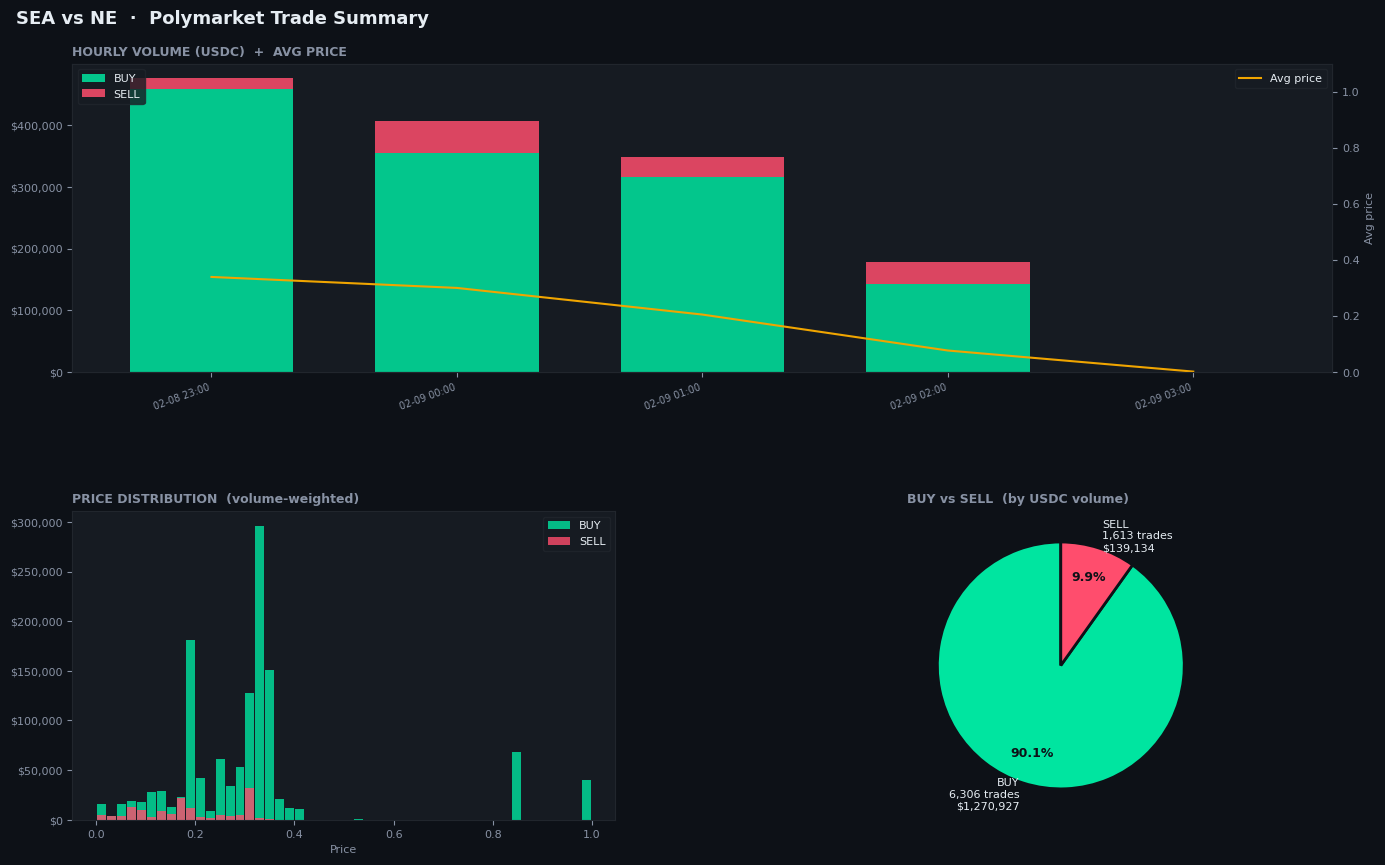

In [ ]:
analyze(df_no)


    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    POLYMARKET SUMMARY  —  SEA vs NE
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Total trades     :        6,941
    Unique wallets   :        2,784
    Date range       : 2026-01-25 → 2026-02-03

    VOLUME (USDC)
    ├─ Total         : $    599,084.15
    ├─ Buy volume    : $    453,435.22  (75.7%)
    ├─ Sell volume   : $    145,648.93  (24.3%)
    ├─ Avg per trade : $       86.3109
    └─ Max trade     : $     64,970.41

    PRICE
    ├─ Overall avg   :        0.6915
    ├─ Buy avg       :        0.6969
    ├─ Sell avg      :        0.6603
    ├─ Min           :        0.0098
    └─ Max           :        0.9900

    TRADE COUNTS
    ├─ Buys          :        5,925  (85.4%)
    └─ Sells         :        1,016  (14.6%)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    
look HERE!
2026-01-25 22:30:08-05:00
2026-02-03 09:11:34-05:00
✓ Saved: polymarket_summary.png


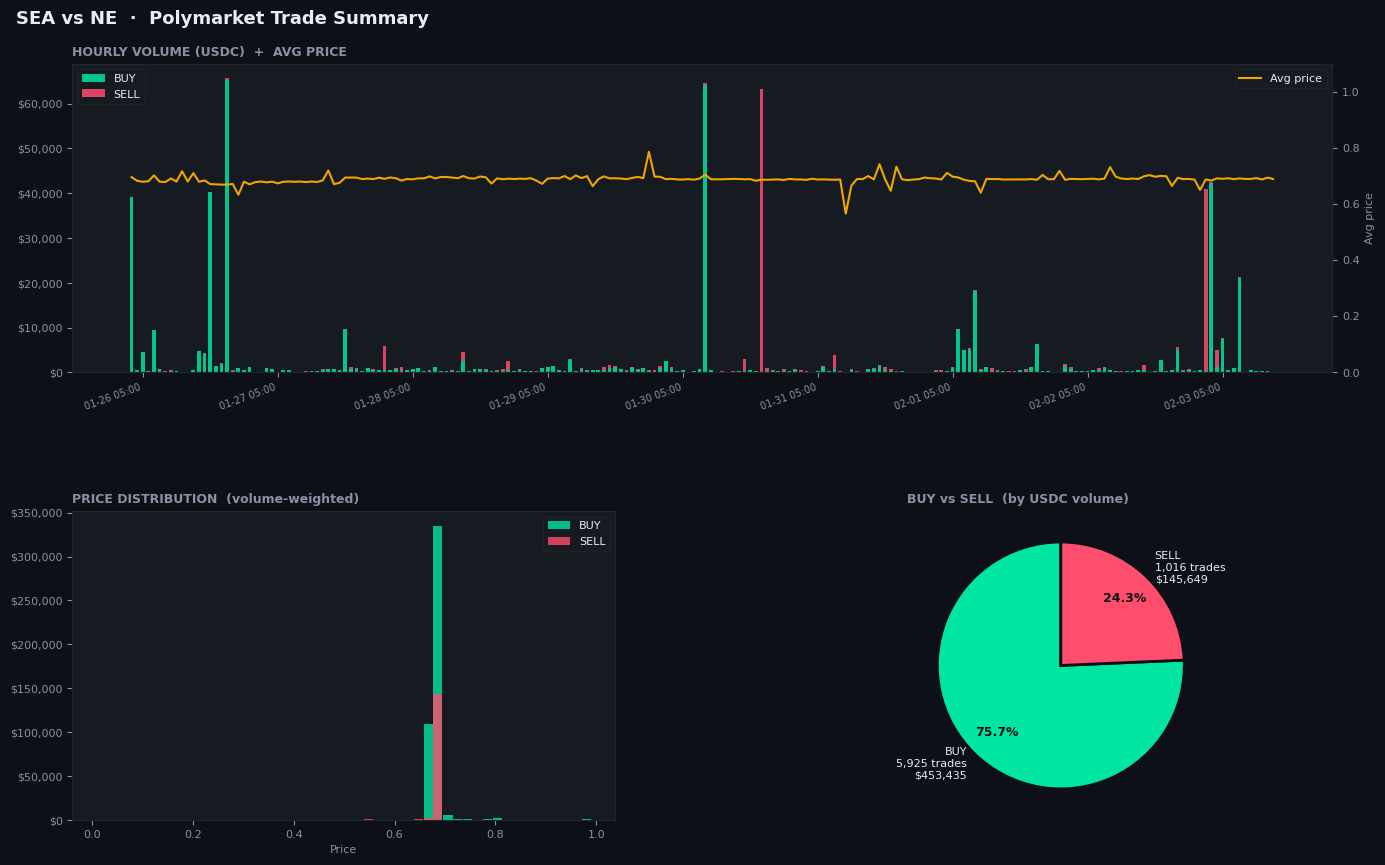

In [ ]:
analyze(yes_full_market)

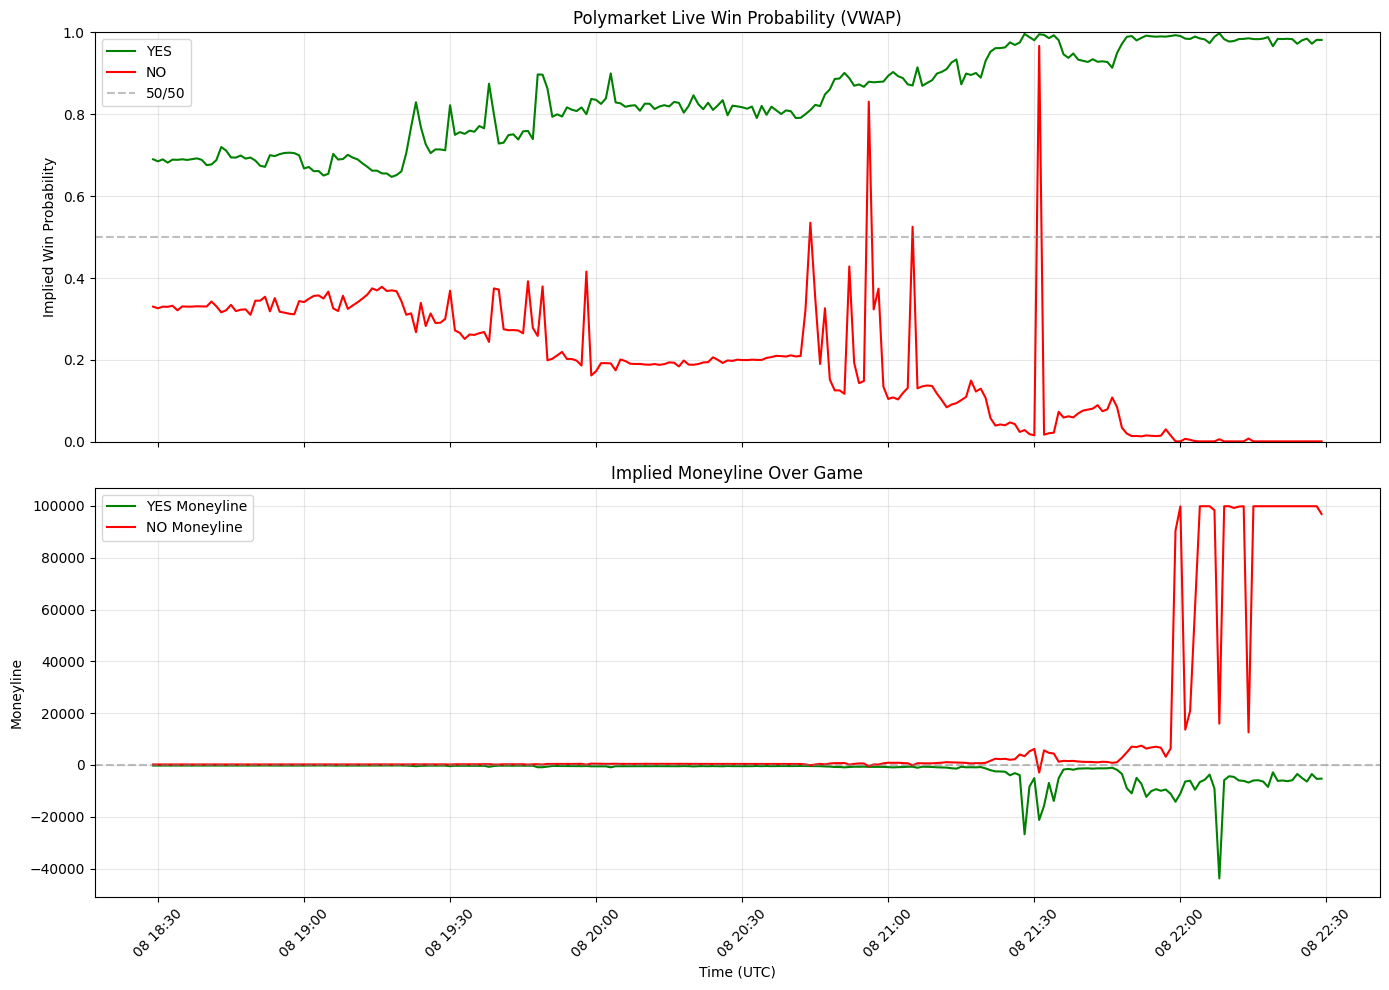

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert timestamps


# Sort
df_yes2 = df_yes.sort_values("timestamp")
df_no2  = df_no.sort_values("timestamp")

# VWAP resample
def vwap_resample(df, freq="1min"):
    df = df.set_index("timestamp").copy()
    df["vwap_num"] = df["price"] * df["total_usdc"]
    resampled = df["vwap_num"].resample(freq).sum() / df["total_usdc"].resample(freq).sum()
    return resampled.ffill()

yes_prob = vwap_resample(df_yes2)
no_prob  = vwap_resample(df_no2)

# Convert probability to moneyline
def prob_to_moneyline(prob):
    if prob >= 0.5:
        return -(prob / (1 - prob)) * 100
    else:
        return ((1 - prob) / prob) * 100

yes_ml = yes_prob.apply(prob_to_moneyline)
no_ml  = no_prob.apply(prob_to_moneyline)

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: implied probability
ax1.plot(yes_prob.index, yes_prob, label="YES", color="green", linewidth=1.5)
ax1.plot(no_prob.index,  no_prob,  label="NO",  color="red",   linewidth=1.5)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="50/50")
ax1.set_ylim(0, 1)
ax1.set_ylabel("Implied Win Probability")
ax1.set_title("Polymarket Live Win Probability (VWAP)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: moneyline
ax2.plot(yes_ml.index, yes_ml, label="YES Moneyline", color="green", linewidth=1.5)
ax2.plot(no_ml.index,  no_ml,  label="NO Moneyline",  color="red",   linewidth=1.5)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Moneyline")
ax2.set_xlabel("Time (UTC)")
ax2.set_title("Implied Moneyline Over Game")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

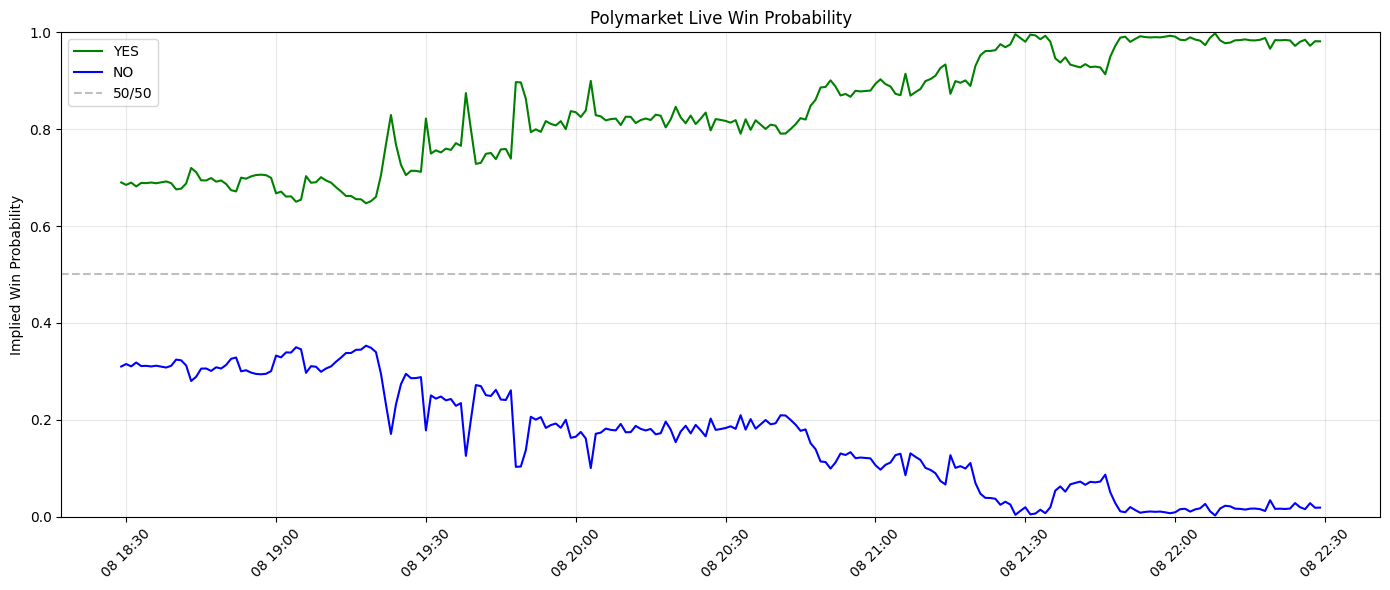

In [ ]:
no_prob_derived = 1 - yes_prob
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(yes_prob.index, yes_prob,         label="YES", color="green", linewidth=1.5)
ax1.plot(yes_prob.index, no_prob_derived,  label="NO",  color="blue",  linewidth=1.5)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="50/50")
ax1.set_ylim(0, 1)
ax1.set_ylabel("Implied Win Probability")
ax1.set_title("Polymarket Live Win Probability")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Market Volume of yes_token

In [ ]:
import requests

r = requests.get(
    "https://gamma-api.polymarket.com/markets",
    params={"clob_token_ids": yes_token_id}
)
market = r.json()[0]
market

print(f"Question    : {market['question']}")
print(f"Created at  : {market['createdAt']}")   # when market opened for trading ✅
print(f"Start date  : {market['startDate']}")   # kickoff time
print(f"End date    : {market['endDate']}")     # kickoff time (same as start)
print(f"Volume      : ${market['volumeNum']:,.2f}")


NameError: name 'yes_token_id' is not defined

## Block chain explorer start

In [ ]:
# import os
# POLYGONSCAN_API_KEY = os.getenv("ETHERSCAN_KEY")

# """
# NFL Polymarket Trade Downloader
# ================================
# Automatically downloads Polymarket trade data for every NFL game
# across the 2023-24 and 2024-25 seasons using the poly CLI tool.

# Setup:
#     1. Get a free Polygonscan API key at: https://polygonscan.com/apis
#     2. Make sure your .env file has: ETHERSCAN_KEY=your_key_here
#     3. Make sure your poly virtual environment is activated:
#            .venv\Scripts\activate   (Windows)
#     4. Run:
#            python nfl_polymarket_downloader.py

# Output:
#     A folder called `nfl_trades/` containing one CSV per game,
#     e.g. nfl_trades/2024_Chiefs_vs_Eagles_2025-02-09.csv
# """


# import pandas as pd
# import requests
# import subprocess
# import os
# import sys
# import time
# from datetime import datetime, timedelta, timezone
# from dotenv import load_dotenv
# import pytz

# load_dotenv()
# print("Current directory:", os.getcwd())
# print("ETHERSCAN_KEY:", os.getenv("ETHERSCAN_KEY"))

# # Check if .env file exists here
# print(".env exists:", os.path.exists(".env"))

# POLYGONSCAN_API_KEY = os.getenv("ETHERSCAN_KEY")
# print(f"Using API key: {POLYGONSCAN_API_KEY}")

# ─────────────────────────────────────────────
# POLYMARKET API - get market open/close times
# ─────────────────────────────────────────────

import os
POLYGONSCAN_API_KEY = os.getenv("ETHERSCAN_KEY")

"""
NFL Polymarket Trade Downloader
================================
Automatically downloads Polymarket trade data for every NFL game
across the 2023-24 and 2024-25 seasons using the poly CLI tool.

Setup:
    1. Get a free Polygonscan API key at: https://polygonscan.com/apis
    2. Make sure your .env file has: ETHERSCAN_KEY=your_key_here
    3. Make sure your poly virtual environment is activated:
           .venv\Scripts\activate   (Windows)
    4. Run:
           python nfl_polymarket_downloader.py

Output:
    A folder called `nfl_trades/` containing one CSV per game,
    e.g. nfl_trades/2024_Chiefs_vs_Eagles_2025-02-09.csv
"""


import pandas as pd
import requests
import subprocess
import os
import sys
import time
from datetime import datetime, timedelta, timezone
from dotenv import load_dotenv
import pytz

load_dotenv()

load_dotenv()
print("Current directory:", os.getcwd())
print("ETHERSCAN_KEY:", os.getenv("ETHERSCAN_KEY"))

# Check if .env file exists here
print(".env exists:", os.path.exists(".env"))

POLYGONSCAN_API_KEY = os.getenv("ETHERSCAN_KEY")
print(f"Using API key: {POLYGONSCAN_API_KEY}")

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

OUTPUT_DIR          = "nfl_trades"   # folder where CSVs will be saved
GAME_DURATION_HOURS = 4              # hours after kickoff to capture
MAX_RPS             = 30             # poly download rate limit (lower = safer)

def get_nfl_schedule() -> list:
    url = "https://github.com/nflverse/nfldata/raw/master/data/games.csv"
    df = pd.read_csv(url)
    df = df[df["season"].isin([2023, 2025])]
    df = df.dropna(subset=["gameday", "gametime"])

    games = []
    for _, row in df.iterrows():
        try:
            dt_str = f"{row['gameday']} {row['gametime']}"
            start_time = datetime.strptime(dt_str, "%Y-%m-%d %H:%M").replace(tzinfo=timezone.utc)
            end_time = start_time + timedelta(hours=GAME_DURATION_HOURS)

            games.append({
                "game_id":     row["game_id"],
                "name":        f"{row['away_team']} vs {row['home_team']}",
                "start_time":  start_time,
                "end_time":    end_time,
                "season":      row["season"],
                "season_type": row["game_type"],
                "week":        row["week"],
            })
        except Exception as e:
            continue

    print(f"Found {len(games)} games total")
    return games

def get_polymarket_market_times(yes_token_id: str) -> dict:
    """
    Query Polymarket Gamma API to get the true market open/close times.
    Returns dict with 'start_time' and 'end_time' as UTC datetime objects.
    """
    r = requests.get(
        "https://gamma-api.polymarket.com/markets",
        params={"clob_token_ids": yes_token_id}
    )
    market = r.json()[0]

    start_time = datetime.fromisoformat(market["createdAt"].replace("Z", "+00:00"))
    end_time   = datetime.fromisoformat(market["closedTime"].replace("Z", "+00:00"))

    print(f"    Polymarket market window:")
    print(f"      createdAt  : {market['createdAt']}")
    print(f"      closedTime : {market['closedTime']}")
    print(f"      volume     : ${market['volumeNum']:,.2f}")

    return {"start_time": start_time, "end_time": end_time}
def run_poly_download(start_block: int, end_block: int, output_file: str):
    POLY_CMD = r"C:\Users\peter\OneDrive\Desktop\poly-trade-scan\.venv\Scripts\poly.exe"

    cmd = [
        POLY_CMD, "download",
        "--start",   str(start_block),
        "--end",     str(end_block),
        "--max-rps", str(MAX_RPS),
        "-o",        output_file,
    ]
    print(f"    Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, text=True, capture_output=True)

    # Print raw output so we can see what poly returned
    print("    STDOUT:", result.stdout[:500] if result.stdout else "empty")
    print("    STDERR:", result.stderr[:500] if result.stderr else "empty")
    print("    Return code:", result.returncode)

    # Try to read the saved file into a dataframe
    if os.path.exists(output_file) and os.path.getsize(output_file) > 0:
        df = pd.read_csv(output_file)
        print(f"    Rows in CSV: {len(df)}")
        print(df.head())
        return df
    else:
        print("    File is empty or missing")
        return None

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
def get_block_at_timestamp(unix_ts: int, closest: str = "before") -> int:
    url = (
        f"https://api.etherscan.io/v2/api"
        f"?chainid=137"  # 137 = Polygon
        f"&module=block&action=getblocknobytime"
        f"&timestamp={unix_ts}&closest={closest}"
        f"&apikey={POLYGONSCAN_API_KEY}"
    )
    r = requests.get(url, timeout=10)
    result = r.json()
    if result.get("status") == "1":
        return int(result["result"])
    raise ValueError(f"Polygonscan error: {result.get('message', result)}")

def main(scan_entire_market_period: bool = False):
    if not POLYGONSCAN_API_KEY:
        print("ERROR: ETHERSCAN_KEY not found in .env file.")
        print("Add this line to your .env:  ETHERSCAN_KEY=your_api_key_here")
        sys.exit(1)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    now = datetime.now(tz=timezone.utc)

    print("=== Fetching NFL Schedules ===")
    all_games = get_nfl_schedule()
    # Deduplicate by game_id
    seen = set()
    unique_games = []


    for g in all_games:
        if g["game_id"] not in seen:
            seen.add(g["game_id"])
            unique_games.append(g)

    print(f"\nTotal unique games: {len(unique_games)}")

    #past_games is the main filter for which games we attempt to download. We only want games that have already started (start_time < now).
    past_games = [g for g in unique_games if g["start_time"] < now][-1:]
    print(f"Past games (downloadable): {len(past_games)}")

    print("\n=== Downloading Trade Data ===\n")
    success, skipped, failed = 0, 0, 0

    for i, game in enumerate(past_games, 1):
        date_str    = game["start_time"].strftime("%Y-%m-%d")
        safe_name   = game["name"].replace(" ", "_").replace("/", "-")
        suffix      = "full_market" if scan_entire_market_period else "game_only"
        filename    = f"{game['season']}_{safe_name}_{date_str}_{suffix}.csv"
        output_file = os.path.join(OUTPUT_DIR, filename)

        print(f"[{i}/{len(past_games)}] {game['name']} ({date_str}) [{game['season_type']} W{game['week']}]")
        print(f"    Mode: {'full market period' if scan_entire_market_period else 'game window only'}")

        if os.path.exists(output_file) and os.path.getsize(output_file) > 100:
            print(f"    Already downloaded, skipping.")
            skipped += 1
            continue

        try:
            if scan_entire_market_period:
                if not yes_token_id:
                    print(f"    ERROR: yes_token_id not found in game dict, cannot query Polymarket API.")
                    failed += 1
                    continue

                market_times = get_polymarket_market_times(yes_token_id)
                start_ts = int(market_times["start_time"].timestamp())
                end_ts   = int(market_times["end_time"].timestamp())
            else:
                start_ts = int(game["start_time"].timestamp())
                end_ts   = int(game["end_time"].timestamp())

            print(f"    start_ts : {start_ts}")
            print(f"    end_ts   : {end_ts}")

            start_block = get_block_at_timestamp(start_ts, "before")
            time.sleep(0.25)
            end_block   = get_block_at_timestamp(end_ts, "after")
            time.sleep(0.25)

            print(f"    Blocks: {start_block} to {end_block}  ({end_block - start_block:,} blocks)")
            run_poly_download(start_block, end_block, output_file)
            success += 1

        except Exception as e:
            print(f"    ERROR: {e}")
            failed += 1

        time.sleep(1)

    print(f"""
=== Done ===
  Downloaded : {success}
  Skipped    : {skipped} (already existed)
  Failed     : {failed}
  Output dir : {os.path.abspath(OUTPUT_DIR)}/
""")


if __name__ == "__main__":
    main(scan_entire_market_period=False)  # ← flip to True for full market history

Current directory: c:\Users\peter\OneDrive\Desktop\poly-trade-scan
ETHERSCAN_KEY: 91DP2BBQ29FV4P8JEC9CTI6Q89VYRU4S5J
.env exists: True
Using API key: 91DP2BBQ29FV4P8JEC9CTI6Q89VYRU4S5J
=== Fetching NFL Schedules ===
Found 570 games total

Total unique games: 570
Past games (downloadable): 1

=== Downloading Trade Data ===

[1/1] SEA vs NE (2026-02-08) [SB W22]
    Mode: game window only
    Already downloaded, skipping.

=== Done ===
  Downloaded : 0
  Skipped    : 1 (already existed)
  Failed     : 0
  Output dir : c:\Users\peter\OneDrive\Desktop\poly-trade-scan\nfl_trades/



## Get Polymarket Data

## Block chain explorer end

In [ ]:
import requests

base = "https://sports.core.api.espn.com"

url = base + "/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/plays?limit=400"

data = requests.get(url).json()

plays = []

for item in data["items"]:
    play_url = item["$ref"]
    play_data = requests.get(play_url).json()
    plays.append(play_data)

print(len(plays))

206


In [ ]:
import json
import re
from time import sleep

import pandas as pd
import requests

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATE_START = "2025-11-01"
DATE_END   = "2026-03-10"
INTERVAL   = "max"   # full history window
FIDELITY   = 500     # number of points requested from CLOB
# ─────────────────────────────────────────────────────────────────────────────

GAMMA_URL = "https://gamma-api.polymarket.com/events"
CLOB_URL  = "https://clob.polymarket.com/prices-history"

# ── STEP 1: Fetch NFL events ──────────────────────────────────────────────────
def fetch_nfl_events(date_start, date_end):
    all_events, offset = [], 0
    while True:
        params = {
            "limit": 200,
            "offset": offset,
            "closed": True,
            "tag_slug": "nfl",
            "start_date_min": date_start,
            "start_date_max": date_end,
        }
        r = requests.get(GAMMA_URL, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        if not data:
            break
        all_events.extend(data)
        print(f"  Fetched {len(all_events)} NFL events...")
        if len(data) < 200:
            break
        offset += 200
    return all_events

# ── STEP 2: Filter to actual game markets only ────────────────────────────────
GAME_PATTERNS = [
    r"will the .+ beat the .+\?",
    r"will .+ beat .+\?",
    r"will .+ win .+\?",
    r".+ vs\.? .+",
]

EXCLUDE_KEYWORDS = [
    "rookie of the year", "mvp", "super bowl mvp", "most passing",
    "most rushing", "most receiving", "division", "conference",
    "make the playoffs", "win the super bowl", "nfc", "afc",
    "heisman", "coach", "draft", "total wins", "over/under"
]

def is_game_market(question: str) -> bool:
    q = str(question).lower()
    if any(kw in q for kw in EXCLUDE_KEYWORDS):
        return False
    return any(re.search(p, q) for p in GAME_PATTERNS)

def _parse_token_ids(raw_value):
    if raw_value is None:
        return []
    if isinstance(raw_value, list):
        return [str(v).strip() for v in raw_value if str(v).strip()]
    if isinstance(raw_value, str):
        raw_value = raw_value.strip()
        if not raw_value:
            return []
        try:
            parsed = json.loads(raw_value)
        except json.JSONDecodeError:
            return []
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    return []

def _extract_winner(market: dict) -> str | None:
    """
    Try multiple fields to find the resolution outcome.
    Gamma API is inconsistent — different endpoints use different keys.
    """
    for key in ("winner", "resolutionTitle", "outcome", "resolvedOutcome"):
        val = market.get(key)
        if val is not None and str(val).strip().lower() not in ("", "none", "null"):
            return str(val).strip()
    return None

def extract_game_markets(events):
    rows = []
    for event in events:
        for market in event.get("markets", []) or []:
            q = market.get("question", "")
            if not is_game_market(q):
                continue

            token_ids = _parse_token_ids(market.get("clobTokenIds"))

            rows.append({
                "event_id":    event.get("id"),
                "event_title": event.get("title"),
                # ✅ end_date is the actual game time; start_date is when the market opened
                "game_date":   market.get("endDate") or event.get("endDate"),
                "market_open": event.get("startDate"),
                "market_id":   market.get("id"),
                "condition_id": market.get("conditionId"),
                # ✅ Store both YES and NO token ids
                "yes_token_id": token_ids[0] if len(token_ids) > 0 else None,
                "no_token_id":  token_ids[1] if len(token_ids) > 1 else None,
                # Keep token_id as YES for backward compatibility with CLOB fetcher
                "token_id":    token_ids[0] if len(token_ids) > 0 else None,
                "question":    q,
                # ✅ Cast volume to float safely
                "volume":      float(market.get("volume") or 0),
                "liquidity":   float(market.get("liquidity") or 0),
                # ✅ Try multiple fields to find the winner
                "winner":      _extract_winner(market),
            })
    return pd.DataFrame(rows)

def attach_token_ids_from_events(games_df: pd.DataFrame, events) -> pd.DataFrame:
    """Backfill token_id by market_id in case games_df was created before token_id existed."""
    if games_df.empty or "market_id" not in games_df.columns:
        return games_df.copy()

    mapping_rows = []
    for event in events:
        for market in event.get("markets", []) or []:
            token_ids = _parse_token_ids(market.get("clobTokenIds"))
            mapping_rows.append({
                "market_id":    market.get("id"),
                "token_id_event": token_ids[0] if token_ids else None,
            })

    map_df = pd.DataFrame(mapping_rows)
    if map_df.empty:
        out = games_df.copy()
        if "token_id" not in out.columns:
            out["token_id"] = None
        return out

    map_df = map_df.dropna(subset=["market_id"]).drop_duplicates("market_id", keep="first")

    out = games_df.copy()
    if "token_id" not in out.columns:
        out["token_id"] = None

    out = out.merge(map_df, on="market_id", how="left")
    out["token_id"] = out["token_id"].fillna(out["token_id_event"])
    out = out.drop(columns=["token_id_event"])
    return out

# ── STEP 3: Fetch price history using CLOB token_id ──────────────────────────
def fetch_price_history(token_id: str, interval: str = "max", fidelity: int = 500):
    token = "" if token_id is None else str(token_id).strip()
    if not token:
        return pd.DataFrame(), "missing_token_id"

    params = {"market": token, "interval": interval, "fidelity": fidelity}
    try:
        r = requests.get(CLOB_URL, params=params, timeout=20)
        if r.status_code != 200:
            return pd.DataFrame(), f"http_{r.status_code}"

        payload = r.json()
        history = payload.get("history", []) if isinstance(payload, dict) else []
        if not history:
            return pd.DataFrame(), "empty_history"

        df = pd.DataFrame(history)
        if not {"t", "p"}.issubset(df.columns):
            return pd.DataFrame(), "unexpected_schema"

        df["timestamp"] = pd.to_datetime(df["t"], unit="s", errors="coerce")
        df["yes_price"]  = pd.to_numeric(df["p"], errors="coerce")
        df = df.dropna(subset=["timestamp", "yes_price"]).sort_values("timestamp")
        if df.empty:
            return pd.DataFrame(), "no_valid_points"

        df["no_price"] = 1 - df["yes_price"]
        return df[["timestamp", "yes_price", "no_price"]], "ok"
    except Exception as e:
        return pd.DataFrame(), f"error:{type(e).__name__}"

# ── STEP 4: Build full time-series dataset + status table ────────────────────
def build_price_timeseries(games_df: pd.DataFrame, interval: str = "max", fidelity: int = 500):
    all_rows    = []
    status_rows = []
    total       = len(games_df)

    for pos, (_, row) in enumerate(games_df.iterrows(), start=1):
        token   = row.get("token_id")
        history, reason = fetch_price_history(token, interval=interval, fidelity=fidelity)

        status = {
            "market_id":   row.get("market_id"),
            "condition_id": row.get("condition_id"),
            "token_id":    token,
            "question":    row.get("question"),
            "event_title": row.get("event_title"),
            "status":      "ok" if not history.empty else "not_possible",
            "reason":      reason,
            "points":      len(history),
        }
        status_rows.append(status)

        if not history.empty:
            history["market_id"]   = row.get("market_id")
            history["condition_id"] = row.get("condition_id")
            history["token_id"]    = token
            history["question"]    = row.get("question")
            history["event_title"] = row.get("event_title")
            # ✅ game_date now correctly uses end_date (actual game time)
            history["game_date"]   = row.get("game_date")
            history["winner"]      = row.get("winner")
            all_rows.append(history)

        if pos % 25 == 0 or pos == total:
            print(f"  processed {pos}/{total}")

        sleep(0.05)

    timeseries_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame(
        columns=[
            "timestamp", "yes_price", "no_price", "market_id", "condition_id",
            "token_id", "question", "event_title", "game_date", "winner"
        ]
    )
    status_df = pd.DataFrame(status_rows)
    return timeseries_df, status_df

# ── MAIN ──────────────────────────────────────────────────────────────────────
print("1. Fetching NFL events...")
events = fetch_nfl_events(DATE_START, DATE_END)

print("\n2. Filtering to game markets...")
games_df = extract_game_markets(events)
print(f"   Found {len(games_df)} game markets")
print(games_df[["question", "event_title", "yes_token_id", "no_token_id", "winner", "volume"]].head(10))

# ── Quick debug: inspect raw market keys from first event ─────────────────────
if events and events[0].get("markets"):
    print("\n[DEBUG] Raw market keys:", list(events[0]["markets"][0].keys()))

1. Fetching NFL events...
  Fetched 200 NFL events...
  Fetched 246 NFL events...

2. Filtering to game markets...
   Found 2342 game markets
                            question          event_title  \
0                Raiders vs. Broncos  Raiders vs. Broncos   
1      Raiders vs. Broncos: O/U 42.5  Raiders vs. Broncos   
2   Raiders vs. Broncos: 1H O/U 21.5  Raiders vs. Broncos   
3  Raiders vs. Broncos: 1H Moneyline  Raiders vs. Broncos   
4   Raiders vs. Broncos: 1H O/U 20.5  Raiders vs. Broncos   
5      Raiders vs. Broncos: O/U 41.5  Raiders vs. Broncos   
6   Raiders vs. Broncos: 1H O/U 22.5  Raiders vs. Broncos   
7                  Falcons vs. Colts    Falcons vs. Colts   
8        Falcons vs. Colts: O/U 48.5    Falcons vs. Colts   
9     Falcons vs. Colts: 1H O/U 24.5    Falcons vs. Colts   

                                        yes_token_id  \
0  5673973454693634924837058814536666838433418864...   
1  1074527365856602690568306049830619812064026863...   
2  258955595371088

## Visualize plays on top of prediction probs

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

skipped_plays = []  # global store for plays missing wallclock

def filter_plays(plays, skip_missing_wallclock=True):
    """Filter plays and track ones missing wallclock."""
    valid, skipped = [], []
    for play in plays:
        if 'wallclock' not in play or not play['wallclock']:
            skipped.append(play)
        else:
            valid.append(play)

    global skipped_plays
    skipped_plays = skipped  # store for later inspection

    if skip_missing_wallclock:
        print(f"Skipped {len(skipped)} plays missing wallclock. Access via `skipped_plays`.")
        return valid
    return plays


# --- Version 1: Event Overlay ---
def plot_event_overlay(plays, yes_prob, skip_missing_wallclock=True, scoring_only=False):
    valid_plays = filter_plays(plays, skip_missing_wallclock)

    if scoring_only:
        valid_plays = [p for p in valid_plays if p.get('scoringPlay')]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(yes_prob.index, yes_prob.values, label='Win Probability')

    for play in valid_plays:
        t = pd.to_datetime(play['wallclock'])
        label = play.get('shortText', '')
        color = 'red' if play.get('scoringPlay') else 'gray'
        ax.axvline(t, color=color, alpha=0.4, linewidth=1)
        ax.text(t, ax.get_ylim()[1], label, rotation=90, fontsize=6, va='top')

    plt.tight_layout()
    plt.show()

def compute_odds_deltas(plays, yes_prob, pre_sec=60, post_sec=60, skip_missing_wallclock=True):
    valid_plays = filter_plays(plays, skip_missing_wallclock)

    def odds_delta(play):
        t = pd.to_datetime(play['wallclock'])
        pre  = yes_prob[(yes_prob.index >= t - pd.Timedelta(seconds=pre_sec)) & (yes_prob.index <= t)].mean()
        post = yes_prob[(yes_prob.index >= t) & (yes_prob.index <= t + pd.Timedelta(seconds=post_sec))].mean()
        print("pre:", pre, "post:", post)
        return post - pre

    results = []
    for play in valid_plays:
        results.append({
            'time': play['wallclock'],
            'text': play.get('shortText'),
            'type': play['type']['text'],
            'yards': play.get('statYardage', 0),
            'scoring': play.get('scoringPlay'),
            'turnover': play.get('isTurnover'),
            'delta': odds_delta(play)
        })

    return pd.DataFrame(results).sort_values('delta', key=abs, ascending=False)


# --- Version 3: Play Type Breakdown ---
def play_type_summary(plays, yes_prob, skip_missing_wallclock=True):
    df = compute_odds_deltas(plays, yes_prob, skip_missing_wallclock=skip_missing_wallclock)
    df['abs_delta'] = df['delta'].abs()

    return df.groupby('type').agg(
        count=('delta', 'count'),
        avg_delta=('delta', 'mean'),
        avg_abs_delta=('abs_delta', 'mean'),
        max_impact=('abs_delta', 'max')
    ).sort_values('avg_abs_delta', ascending=False), df


# --- Version 4: Yards vs Odds Correlation ---
def yards_vs_odds(plays, yes_prob, skip_missing_wallclock=True):
    df = compute_odds_deltas(plays, yes_prob, skip_missing_wallclock=skip_missing_wallclock)
    filtered = df.dropna(subset=['yards', 'delta'])

    slope, intercept, r, p, se = stats.linregress(filtered['yards'], filtered['delta'])

    plt.scatter(filtered['yards'], filtered['delta'], alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.plot(filtered['yards'], slope * filtered['yards'] + intercept, color='red')
    plt.xlabel('Yards Gained')
    plt.ylabel('Odds Delta')
    plt.title(f'r={r:.2f}, p={p:.3f}')
    plt.show()

In [ ]:
for key in plays[5].keys():
    print(key, ":", (plays[5][key]))

$ref : http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/plays/401772988131?lang=en&region=us
id : 401772988131
sequenceNumber : 13100
type : {'id': '24', 'text': 'Pass Reception', 'abbreviation': 'REC'}
text : (No Huddle) S.Darnold pass deep left to C.Kupp pushed ob at NE 17 for 23 yards (M.Jones).
shortText : Sam Darnold Pass Complete for 23 Yds to Cooper Kupp
alternativeText : (No Huddle) S.Darnold pass deep left to C.Kupp pushed ob at NE 17 for 23 yards (M.Jones).
shortAlternativeText : Sam Darnold Pass Complete for 23 Yds to Cooper Kupp
awayScore : 0
homeScore : 0
period : {'number': 1}
clock : {'value': 805.0, 'displayValue': '13:25'}
scoringPlay : False
priority : False
scoreValue : 0
modified : 2026-02-09T03:39Z
team : {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/seasons/2025/teams/26?lang=en&region=us'}
participants : [{'athlete': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/league

In [ ]:
type_dict = {}
type_abbr_lst=[]
for play in plays:
    if "abbreviation" in play['type'] and "text" in play['type']:
        type_dict[play['type']['text']] = play['type']['abbreviation']
    elif "text" in play['type']:
        type_dict[play['type']['text']] = ""


# Option 2: sorted set - unique + alphabetically sorted
print("Type Texts:", sorted(set(type_dict.keys())))
print("Type Abbreviations:", sorted(set(type_dict.values())))

Type Texts: ['Coin Toss', 'End Period', 'End of Game', 'End of Half', 'Field Goal Good', 'Interception Return Touchdown', 'Kickoff', 'Official Timeout', 'Pass Incompletion', 'Pass Interception Return', 'Pass Reception', 'Passing Touchdown', 'Penalty', 'Punt', 'Rush', 'Sack', 'Sack Opp Fumble Recovery', 'Timeout', 'Two-minute warning']
Type Abbreviations: ['', '2Min Warn', 'EG', 'EH', 'EP', 'FG', 'INTR', 'K', 'Off TO', 'PEN', 'PUNT', 'REC', 'RUSH', 'SFOP', 'TD', 'TO']


Skipped 5 plays missing wallclock. Access via `skipped_plays`.
Skipped 0 plays missing wallclock. Access via `skipped_plays`.


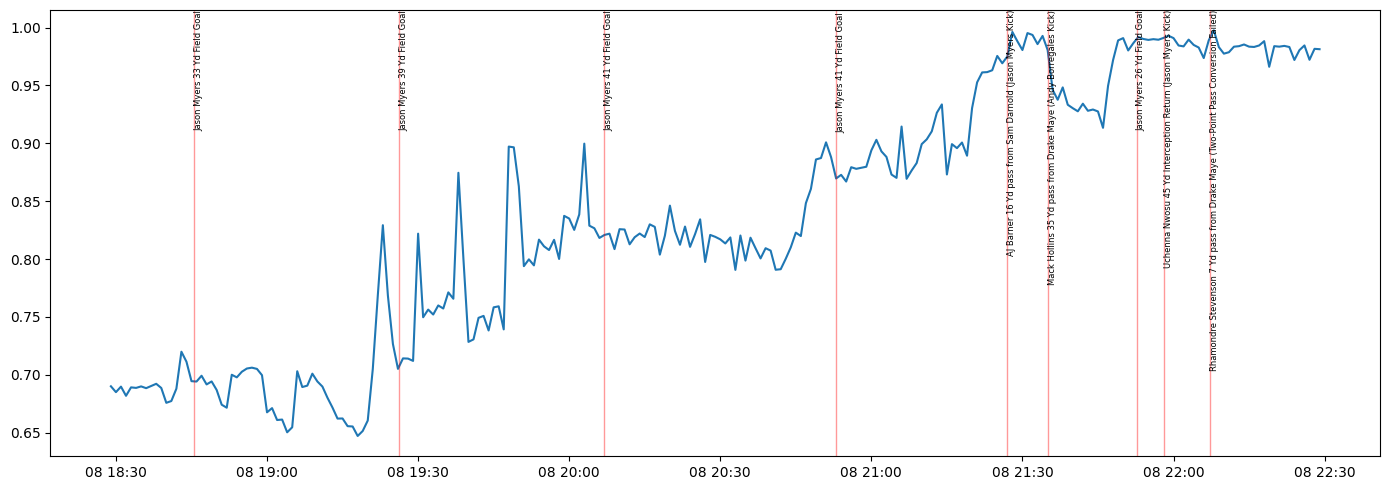

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


filtered = filter_plays(plays, skip_missing_wallclock=True)
plot_event_overlay(filtered, yes_prob, skip_missing_wallclock=True,scoring_only=True)

In [ ]:

# import plotly.graph_objects as go
# import pandas as pd
# def plot_event_overlay_interactive(plays, yes_prob, skip_missing_wallclock=True, scoring_only=False):
#     valid_plays = filter_plays(plays, skip_missing_wallclock)

#     if scoring_only:
#         valid_plays = [p for p in valid_plays if p.get('scoringPlay')]

#     fig = go.Figure()

#     fig.add_trace(go.Scatter(
#         x=yes_prob.index,
#         y=yes_prob.values,
#         mode='lines',
#         name='Win Probability',
#         line=dict(color='#1f77b4', width=2)
#     ))

#     for play in valid_plays:
#         t = pd.to_datetime(play['wallclock']).tz_convert('America/New_York')
#         is_scoring = play.get('scoringPlay', False)
#         is_turnover = play.get('isTurnover', False)

#         if is_scoring:
#             color, dash = 'red', 'solid'
#         elif is_turnover:
#             color, dash = 'orange', 'dash'
#         else:
#             color, dash = 'rgba(150,150,150,0.4)', 'dot'

#         fig.add_vline(
#             x=t,
#             line=dict(color=color, width=1.5, dash=dash),
#         )

#         fig.add_trace(go.Scatter(
#             x=[t],
#             y=[yes_prob.asof(t) if hasattr(yes_prob, 'asof') else yes_prob.iloc[0]],
#             mode='markers',
#             marker=dict(size=8, color=color, symbol='line-ns', line=dict(width=2, color=color)),
#             text=f"<b>{play.get('shortText', '')}</b><br>"
#                  f"Type: {play['type']['text']}<br>"
#                  f"Yards: {play.get('statYardage', 'N/A')}<br>"
#                  f"Scoring: {is_scoring}<br>"
#                  f"Turnover: {is_turnover}<br>"
#                  f"Time: {t}",
#             hoverinfo='text',
#             showlegend=False
#         ))

#     fig.update_layout(
#         title='Win Probability with Play Events',
#         xaxis_title='Time',
#         yaxis_title='Win Probability',
#         yaxis=dict(range=[0, 1]),
#         hovermode='closest',
#         height=500,
#         template='plotly_dark',
#     )

#     fig.show()


def plot_event_overlay_interactive(plays, yes_prob, team_id, skip_missing_wallclock=True, scoring_only=False):
    valid_plays = filter_plays(plays, skip_missing_wallclock)

    if scoring_only:
        valid_plays = [p for p in valid_plays if p.get('scoringPlay')]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=yes_prob.index,
        y=yes_prob.values,
        mode='lines',
        name='Win Probability',
        line=dict(color='#1f77b4', width=2)
    ))

    for play in valid_plays:
        t = pd.to_datetime(play['wallclock']).tz_convert('America/New_York')

        # Match t to whatever yes_prob.index is
        if yes_prob.index.tz is None:
            t = t.tz_localize(None)  # strip tz
        else:
            t = t.tz_convert(yes_prob.index.tz)  # match tz
        is_scoring = play.get('scoringPlay', False)
        is_turnover = play.get('isTurnover', False)
        play_type  = play['type'].get('abbreviation', '').upper()

        # extract team id from $ref URL
        play_team_id = str(play.get('team', {}).get('$ref', '').split('teams/')[-1].split('?')[0])
        is_our_team = play_team_id == str(team_id)

        if is_scoring:
            is_td = play_type in ('TD', 'PTD', 'RTD', 'RZTD')
            is_fg = play_type in ('FG', 'FGMADE')

            if is_our_team:
                color = 'red'
            else:
                color = 'green'

            if is_td:
                dash = 'solid'
            elif is_fg:
                dash = 'dot'
            else:
                dash = 'dash'  # PAT, 2pt, etc.

        elif is_turnover:
            color, dash = 'orange', 'dash'
        else:
            color, dash = 'rgba(150,150,150,0.4)', 'dot'

        fig.add_vline(
            x=t,
            line=dict(color=color, width=1.5, dash=dash),
        )

        fig.add_trace(go.Scatter(
            x=[t],
            y=[yes_prob.asof(t) if hasattr(yes_prob, 'asof') else yes_prob.iloc[0]],
            mode='markers',
            marker=dict(size=8, color=color, symbol='line-ns', line=dict(width=2, color=color)),
            text=f"<b>{play.get('shortText', '')}</b><br>"
                 f"Type: {play['type']['text']}<br>"
                 f"Abbreviation: {play_type}<br>"
                 f"Team ID: {play_team_id}<br>"
                 f"Yards: {play.get('statYardage', 'N/A')}<br>"
                 f"Scoring: {is_scoring}<br>"
                 f"Turnover: {is_turnover}<br>"
                 f"Time: {t}",
            hoverinfo='text',
            showlegend=False
        ))

    fig.update_layout(
        title='Win Probability with Play Events',
        xaxis_title='Time',
        yaxis_title='Win Probability',
        yaxis=dict(autorange=True),
        hovermode='closest',
        height=500,
        template='simple_white',
    )

    fig.show()

In [ ]:
def plot_event_overlay_interactive(plays, yes_prob, team_id, skip_missing_wallclock=True, scoring_only=False):
    valid_plays = filter_plays(plays, skip_missing_wallclock)

    # Sort by time for possession shading
    sorted_plays = sorted(valid_plays, key=lambda p: pd.to_datetime(p['wallclock']))

    fig = go.Figure()

    # --- Possession shading ---
    for i, play in enumerate(sorted_plays[:-1]):
        next_play = sorted_plays[i + 1]

        current_period = play['period']['number']
        next_period = next_play['period']['number']

        # Skip halftime (gap between Q2 and Q3)


        t_start = pd.to_datetime(play['wallclock']).tz_convert('America/New_York')
        t_end   = pd.to_datetime(next_play['wallclock']).tz_convert('America/New_York')

        if yes_prob.index.tz is None:
            t_start = t_start.tz_localize(None)
            t_end   = t_end.tz_localize(None)
        else:
            t_start = t_start.tz_convert(yes_prob.index.tz)
            t_end   = t_end.tz_convert(yes_prob.index.tz)

        play_team_id = str(play.get('team', {}).get('$ref', '').split('teams/')[-1].split('?')[0])
        is_turnover = play.get('isTurnover', False)

        # Skip halftime (gap between Q2 and Q3)
        if current_period == 2 and next_period == 3:
            color = 'gold'
        elif is_turnover:
            color = 'blue'
        elif play_team_id == str(team_id):
            color = 'black'
        else:
            color = 'white'

        fig.add_vrect(
            x0=t_start, x1=t_end,
            fillcolor=color, opacity=0.15,
            layer='below', line_width=0
        )

        fig.add_vrect(
            x0=t_start, x1=t_end,
            fillcolor=color, opacity=0.15,
            layer='below', line_width=0
        )


    # --- Win probability line ---
    fig.add_trace(go.Scatter(
        x=yes_prob.index,
        y=yes_prob.values,
        mode='lines',
        name='Win Probability',
        line=dict(color='#1f77b4', width=2)
    ))

    # --- Play markers ---
    if scoring_only:
        valid_plays = [p for p in valid_plays if p.get('scoringPlay')]

    for play in valid_plays:
        t = pd.to_datetime(play['wallclock']).tz_convert('America/New_York')

        if yes_prob.index.tz is None:
            t = t.tz_localize(None)
        else:
            t = t.tz_convert(yes_prob.index.tz)

        is_scoring = play.get('scoringPlay', False)
        is_turnover = play.get('isTurnover', False)
        play_type = play['type'].get('abbreviation', '').upper()
        play_team_id = str(play.get('team', {}).get('$ref', '').split('teams/')[-1].split('?')[0])
        is_our_team = play_team_id == str(team_id)

        if is_scoring:
            is_td = play_type in ('TD', 'PTD', 'RTD', 'RZTD')
            color = 'red' if is_our_team else 'green'
            dash  = 'solid' if is_td else 'dot'
        elif is_turnover:
            color, dash = 'orange', 'dash'
        else:
            color, dash = 'rgba(150,150,150,0.4)', 'dot'

        fig.add_vline(x=t, line=dict(color=color, width=1.5, dash=dash))

        fig.add_trace(go.Scatter(
            x=[t],
            y=[yes_prob.asof(t)],
            mode='markers',
            marker=dict(size=8, color=color, symbol='line-ns', line=dict(width=2, color=color)),
            text=f"<b>{play.get('shortText', '')}</b><br>"
                 f"Type: {play['type']['text']}<br>"
                 f"Abbreviation: {play_type}<br>"
                 f"Team ID: {play_team_id}<br>"
                 f"Yards: {play.get('statYardage', 'N/A')}<br>"
                 f"Scoring: {is_scoring}<br>"
                 f"Turnover: {is_turnover}<br>"
                 f"Time: {t}",
            hoverinfo='text',
            showlegend=False
        ))

    fig.update_layout(
        title='Win Probability with Play Events',
        xaxis_title='Time',
        yaxis_title='Win Probability',
        yaxis=dict(autorange=True),
        hovermode='closest',
        height=500,
        template='simple_white',
    )

    fig.show()

In [ ]:
# plot_event_overlay_interactive(filtered, yes_prob)                        # all plays
plot_event_overlay_interactive(filtered, yes_prob, scoring_only=True, team_id=26)     # scoring only

Skipped 0 plays missing wallclock. Access via `skipped_plays`.


In [ ]:
play_type_summary(filtered, yes_prob, skip_missing_wallclock=True)[0]

Skipped 0 plays missing wallclock. Access via `skipped_plays`.
pre: 0.6757220669833008 post: 0.6772676701408786
pre: 0.6772676701408786 post: nan
pre: 0.6772676701408786 post: 0.6879148523343952
pre: 0.6879148523343952 post: 0.7198824634002547
pre: nan post: 0.7198824634002547
pre: 0.7198824634002547 post: 0.7112841427693668
pre: 0.7112841427693668 post: nan
pre: nan post: 0.6944268310786709
pre: nan post: 0.6941091067519723
pre: 0.6944268310786709 post: 0.6941091067519723
pre: nan post: 0.6941858636110032
pre: nan post: 0.6868165760647718
pre: 0.6868165760647718 post: 0.6740786537814839
pre: 0.6740786537814839 post: nan
pre: 0.6740786537814839 post: 0.6714923063865678
pre: 0.6714923063865678 post: 0.6999639499262277
pre: nan post: 0.6999639499262277
pre: 0.6999639499262277 post: 0.6977261216932601
pre: 0.6977261216932601 post: 0.7025703950761977
pre: 0.7025703950761977 post: nan
pre: 0.7025703950761977 post: 0.7053666465613839
pre: 0.705028217959681 post: 0.6996013636484213
pre: 0.699

,count,avg_delta,avg_abs_delta,max_impact
type,,,,
Punt,6,0.011797,0.023738,0.044490
Pass Incompletion,21,0.008847,0.022644,0.158001
Pass Interception Return,1,0.022373,0.022373,0.022373
Rush,20,0.000901,0.019192,0.071649
Pass Reception,23,0.012029,0.019131,0.108871
Kickoff,7,0.017167,0.018636,0.109972
Timeout,5,0.011188,0.014534,0.061168
Official Timeout,6,-0.007173,0.012166,0.045170
Passing Touchdown,1,0.008619,0.008619,0.008619


## Get win probabilities


In [ ]:


url = base + "/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/probabilities?limit=200"

data = requests.get(url).json()

probs = []

for item in data["items"]:
    prob_url = item["$ref"]
    prob_data = requests.get(prob_url).json()
    probs.append(prob_data)

NameError: name 'base' is not defined

In [ ]:
probs[0]

{'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/probabilities/4017729881?lang=en&region=us',
 'competition': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988?lang=en&region=us'},
 'play': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/events/401772988/competitions/401772988/plays/4017729881?lang=en&region=us'},
 'homeTeam': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/seasons/2025/teams/17?lang=en&region=us'},
 'awayTeam': {'$ref': 'http://sports.core.api.espn.com/v2/sports/football/leagues/nfl/seasons/2025/teams/26?lang=en&region=us'},
 'tiePercentage': 0.0,
 'homeWinPercentage': 0.4057,
 'awayWinPercentage': 0.5943,
 'lastModified': '2026-02-09T03:29Z',
 'sequenceNumber': '100',
 'source': {'id': '2', 'description': 'feed', 'state': 'full'},
 'secondsLeft': 0,
 'spreadCoverProbHome': 0.5,
 'spreadPushPro

In [ ]:
prob_dict = {}

for p in probs:

    ref = p["play"]["$ref"]

    play_id = ref.split("/")[-1].split("?")[0]

    prob_dict[play_id] = p

rows = []

for play in plays:

    play_id = play["id"]

    if play_id in prob_dict:
        win_prob = prob_dict[play_id]["homeWinPercentage"]
    else:
        win_prob = None

    rows.append({
        "play_id": play_id,
        "text": play.get("text"),
        "win_prob": win_prob
    })